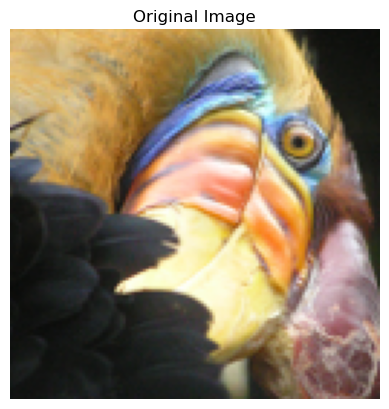

Shape of reshaped image: (16384, 3)


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Load the image (example: 'bird_small.png') 
original_img = plt.imread(r'C:\Users\mahdi\Desktop\CSE445\bird_small.png')  # Replace with your image path

# Display the original image
plt.imshow(original_img)
plt.title('Original Image')
plt.axis('off')
plt.show()

# Reshape the image into an m x 3 matrix where m = number of pixels
# Each row will contain the Red, Green, and Blue pixel values
X_img = np.reshape(original_img, (original_img.shape[0] * original_img.shape[1], 3))

print("Shape of reshaped image:", X_img.shape)  # This will be (m, 3), where m is the number of pixels


In [5]:
def initialize_centroids(X, K):
    """
    Initialize centroids using the k-means++ method to minimize distortion.
    """
    # Choose the first centroid randomly from the data points
    centroids = [X[np.random.randint(0, X.shape[0])]]
    
    for _ in range(1, K):
        # Compute the squared distances from each point to the nearest centroid
        distances = np.min([np.sum((X - c) ** 2, axis=1) for c in centroids], axis=0)
        
        # Probability proportional to the squared distance
        probabilities = distances / np.sum(distances)
        
        # Select the next centroid based on these probabilities
        cumulative_probs = np.cumsum(probabilities)
        r = np.random.rand()
        next_centroid_idx = np.where(cumulative_probs >= r)[0][0]
        centroids.append(X[next_centroid_idx])
    
    return np.array(centroids)

# Set the number of clusters
K = 3  # You can try with K=5 later

# Initialize centroids
initial_centroids = initialize_centroids(X_img, K)
print("Initial centroids (K={}):\n".format(K), initial_centroids)


Initial centroids (K=3):
 [[0.3137255  0.30588236 0.3254902 ]
 [0.7607843  0.6745098  0.44705883]
 [0.57254905 0.39215687 0.24705882]]


In [9]:
def k_means_clustering(X, initial_centroids, max_iters=100):
    """
    Perform K-Means clustering.
    
    Parameters:
        X (ndarray): Dataset of shape (m, n), where m = number of points and n = dimensions.
        initial_centroids (ndarray): Initial centroids of shape (K, n).
        max_iters (int): Maximum number of iterations.
        
    Returns:
        centroids (ndarray): Final centroids after clustering.
        labels (ndarray): Cluster assignments for each data point.
    """
    m, n = X.shape
    K = initial_centroids.shape[0]
    centroids = initial_centroids
    labels = np.zeros(m, dtype=int)
    
    for it in range(max_iters):
        # Step 1: Assign each point to the nearest centroid
        for i in range(m):
            distances = np.linalg.norm(X[i] - centroids, axis=1)
            labels[i] = np.argmin(distances)
        
        # Step 2: Compute new centroids as the mean of assigned points
        new_centroids = np.zeros((K, n))
        for k in range(K):
            points_in_cluster = X[labels == k]
            if points_in_cluster.size > 0:
                new_centroids[k] = np.mean(points_in_cluster, axis=0)
            else:  # Handle empty clusters
                new_centroids[k] = X[np.random.randint(0, m)]
        
        # Check for convergence
        if np.allclose(centroids, new_centroids, atol=1e-6):
            print(f"K-Means converged after {it+1} iterations.")
            break
        
        centroids = new_centroids
    
    return centroids, labels

# Run the K-Means clustering
max_iters = 100
final_centroids, cluster_labels = k_means_clustering(X_img, initial_centroids, max_iters)
print("Final centroids:\n", final_centroids)


K-Means converged after 35 iterations.
Final centroids:
 [[0.15276372 0.14761057 0.13562867]
 [0.88792199 0.80110663 0.64233893]
 [0.63535494 0.50730956 0.35541955]]


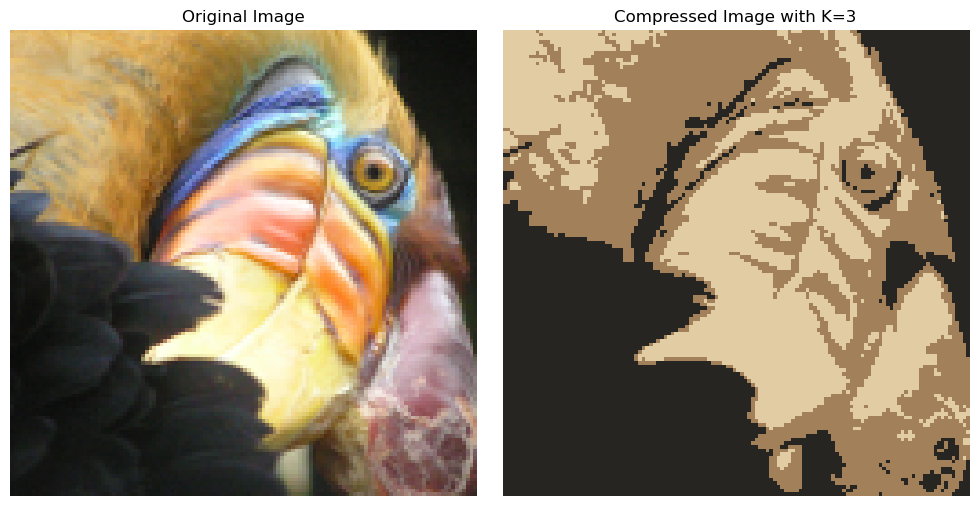

In [11]:
# Reconstruct the image from the clustered data
def reconstruct_image(X, labels, centroids, original_shape):
    """
    Reconstruct the compressed image using the centroids and cluster labels.
    
    Parameters:
        X (ndarray): Dataset of shape (m, n), where m = number of points and n = dimensions.
        labels (ndarray): Cluster assignments for each data point.
        centroids (ndarray): Final centroids after clustering.
        original_shape (tuple): Original shape of the image (height, width, channels).
    
    Returns:
        reconstructed_image (ndarray): The compressed image reshaped to the original dimensions.
    """
    # Assign each pixel the color of its centroid
    X_recovered = centroids[labels]
    # Reshape to the original image dimensions
    reconstructed_image = np.reshape(X_recovered, original_shape)
    return reconstructed_image

# Reconstruct the image
compressed_img = reconstruct_image(X_img, cluster_labels, final_centroids, original_img.shape)

# Display the original and compressed images
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(original_img)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(compressed_img)
ax[1].set_title(f'Compressed Image with K={len(final_centroids)}')
ax[1].axis('off')

plt.tight_layout()
plt.show()


In [38]:
# Calculate distortion (inertia)
def calculate_distortion(X, labels, centroids):
    """
    Calculate the distortion (sum of squared distances between each point and its closest centroid).
    
    Parameters:
        X (ndarray): Dataset of shape (m, n).
        labels (ndarray): Cluster assignments for each data point.
        centroids (ndarray): Final centroids after clustering.
    
    Returns:
        distortion (float): Sum of squared distances between points and their assigned centroids.
    """
    distortion = np.sum((X - centroids[labels]) ** 2)
    return distortion

# Compute distortion for the final clustering
distortion = calculate_distortion(X_img, cluster_labels, final_centroids)

# Print the distortion
print(f"Distortion for K={len(final_centroids)}: {distortion:.2f}")
def compute_distortion(X, cluster_labels, centroids):
    """
    Compute the distortion (sum of squared distances between points and their centroids).
    
    Args:
    - X: Data points (n_samples, n_features).
    - cluster_labels: Labels indicating which centroid each point is assigned to.
    - centroids: Final centroids (K, n_features).
    
    Returns:
    - distortion: Sum of squared distances (float).
    """
    distortion = 0.0
    for i in range(len(X)):
        centroid = centroids[cluster_labels[i]]
        distortion += np.sum((X[i] - centroid) ** 2)
    return distortion



Distortion for K=5: 363.99


In [40]:
def k_means(X, initial_centroids, max_iters):
    
    centroids = initial_centroids
    num_iters = 0
    
    for i in range(max_iters):
        # Step 1: Assign clusters based on nearest centroid
        distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)
        cluster_labels = np.argmin(distances, axis=1)
        
        # Step 2: Compute new centroids as mean of points in each cluster
        new_centroids = np.array([X[cluster_labels == k].mean(axis=0) for k in range(centroids.shape[0])])
        
        # If centroids do not change, convergence is achieved
        if np.allclose(new_centroids, centroids, atol=1e-6):
            break
        
        centroids = new_centroids
        num_iters += 1
    
    return centroids, cluster_labels, num_iters


Initial centroids (K=5):
 [[0.09411765 0.10980392 0.08627451]
 [0.67058825 0.5921569  0.5686275 ]
 [0.6039216  0.8862745  0.9529412 ]
 [0.46666667 0.2509804  0.2       ]
 [0.60784316 0.43529412 0.13333334]]
K-Means converged after 17 iterations.
Final centroids (K=5):
 [[0.1182833  0.1221192  0.11269241]
 [0.80691504 0.68174887 0.49525148]
 [0.9274729  0.8780257  0.75586   ]
 [0.40263397 0.3424898  0.30668756]
 [0.68486315 0.5178898  0.31001586]]
Original image shape: (128, 128, 3)
Recovered image shape: (128, 128, 3)


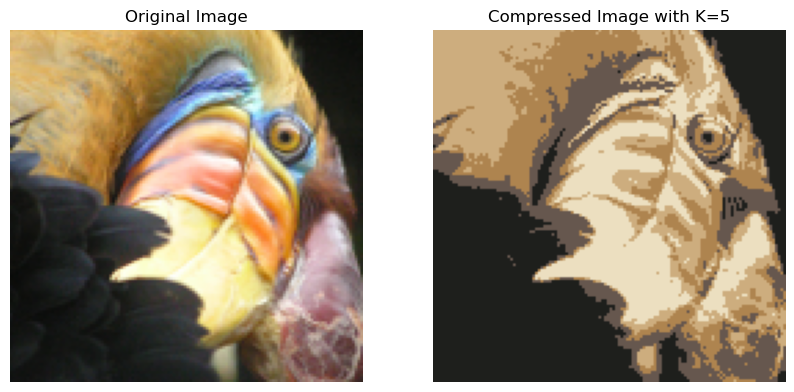

Distortion (K=5): 380.30925467749705


In [48]:
K = 5
max_iters = 100

# Initialize centroids for K=5
initial_centroids = initialize_centroids(X_img, K)
print(f"Initial centroids (K={K}):\n", initial_centroids)

# Run K-Means for K=5
final_centroids, cluster_labels, iterations = k_means(X_img, initial_centroids, max_iters)
print(f"K-Means converged after {iterations} iterations.")
print(f"Final centroids (K={K}):\n", final_centroids)

# Reconstruct the compressed image
X_recovered = final_centroids[cluster_labels, :]
X_recovered = np.reshape(X_recovered, original_img.shape)

# Ensure the image values are clipped to [0, 1] for proper visualization
original_img_clipped = np.clip(original_img, 0, 1)
X_recovered_clipped = np.clip(X_recovered, 0, 1)

# Double-check image shape before plotting
print(f"Original image shape: {original_img_clipped.shape}")
print(f"Recovered image shape: {X_recovered_clipped.shape}")

# Display original and compressed images
fig, ax = plt.subplots(1, 2, figsize=(10, 10))
ax[0].imshow(original_img_clipped)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(X_recovered_clipped)
ax[1].set_title(f'Compressed Image with K={K}')
ax[1].axis('off')

plt.show()

# Compute distortion for K=5
distortion = compute_distortion(X_img, cluster_labels, final_centroids)
print(f"Distortion (K={K}): {distortion}")


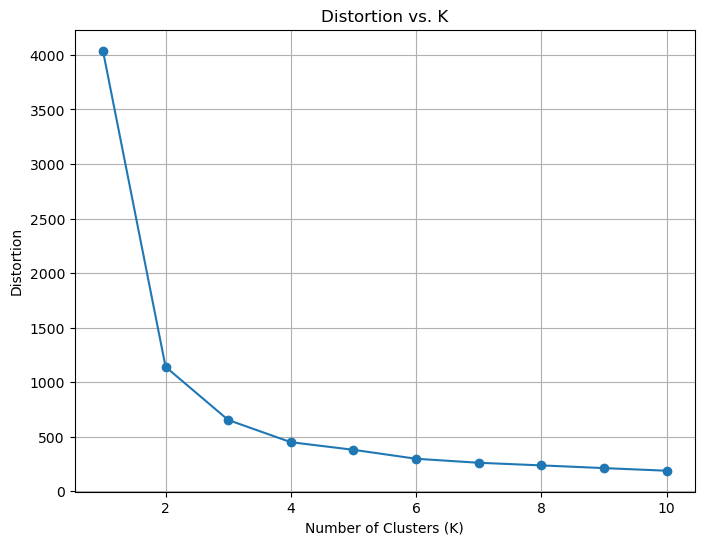

In [50]:
K_range = range(1, 11)  # Test values of K from 1 to 10
distortions = []

for K in K_range:
    initial_centroids = initialize_centroids(X_img, K)
    final_centroids, cluster_labels, iterations = k_means(X_img, initial_centroids, max_iters)
    distortion = compute_distortion(X_img, cluster_labels, final_centroids)
    distortions.append(distortion)

# Plotting Distortion vs K
plt.figure(figsize=(8, 6))
plt.plot(K_range, distortions, marker='o')
plt.title('Distortion vs. K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Distortion')
plt.grid(True)
plt.show()
